# Exploratory Data Analysis: : Part 1
 The dataset comprises a set of timeseries with 79 features and 9 responders, anonymized but representing real market data. The goal of the competition is to forecast one of these responders, i.e., responder_6, for up to six months in the future.
 
You can download the oringial dataset from [here](https://www.kaggle.com/competitions/jane-street-real-time-market-data-forecasting/data).
After downloading the dataset, you can extract the files to the `data` folder.

<font color=red>In this EDA document, the objective is to conduct a comprehensive and detailed review of all files.

The data downloaded from the link can be stored in a `data` folder, which resides at the same level as this `.ipynb` file. The structure is illustrated as follows:

```terminal
├── data
│   ├── features.csv
│   ├── kaggle_evaluation
│   │   ├── __init__.py
│   │   ├── core
│   │   │   ├── __init__.py
│   │   │   ├── base_gateway.py
│   │   │   ├── generated
│   │   │   │   ├── __init__.py
│   │   │   │   ├── kaggle_evaluation_pb2.py
│   │   │   │   └── kaggle_evaluation_pb2_grpc.py
│   │   │   ├── kaggle_evaluation.proto
│   │   │   ├── relay.py
│   │   │   └── templates.py
│   │   ├── jane_street_gateway.py
│   │   └── jane_street_inference_server.py
│   ├── lags.parquet
│   │   └── date_id=0
│   │       └── part-0.parquet
│   ├── responders.csv
│   ├── sample_submission.csv
│   ├── test.parquet
│   │   └── date_id=0
│   │       └── part-0.parquet
│   ├── train.parquet
│   │   ├── partition_id=0
│   │   │   └── part-0.parquet
│   │   ├── partition_id=1
│   │   │   └── part-0.parquet
│   │   ├── partition_id=2
│   │   │   └── part-0.parquet
│   │   ├── partition_id=3
│   │   │   └── part-0.parquet
│   │   ├── partition_id=4
│   │   │   └── part-0.parquet
│   │   ├── partition_id=5
│   │   │   └── part-0.parquet
│   │   ├── partition_id=6
│   │   │   └── part-0.parquet
│   │   ├── partition_id=7
│   │   │   └── part-0.parquet
│   │   ├── partition_id=8
│   │   │   └── part-0.parquet
│   │   └── partition_id=9
│   │       └── part-0.parquet
├── notebooks
│   ├── EDA_Part1.ipynb
│   ├── EDA_Part2.ipynb
│   ├── EDA_Part3_fillna.ipynb
```

In [47]:
import pandas as pd
import numpy as np
import gc
import os
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter, PercentFormatter
import seaborn as sns

import logging
import warnings
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()


## File1: Train.parquet

- **train.parquet** - The training set, contains historical data and returns. For convenience, the training set has been partitioned into ten parts.
  - `date_id` and `time_id` - Integer values that are ordinally sorted, providing a chronological structure to the data, although the actual time intervals between `time_id` values may vary.
  - `symbol_id` - Identifies a unique financial instrument.
  - `weight` - The weighting used for calculating the scoring function.
  - `feature_{00...78}` - Anonymized market data.
  - `responder_{0...8}` - Anonymized responders clipped between -5 and 5. The `responder_6` field is what we are trying to predict.
    
Each row in the `{train/test}.parquet` dataset corresponds to a unique combination of a symbol (identified by `symbol_id`) and a timestamp (represented by `date_id` and `time_id`). You will be provided with multiple responders, with `responder_6` being the only responder used for scoring. The date_id column is an integer which represents the day of the event, while `time_id` represents a time ordering. It's important to note that the real time differences between each time_id are not guaranteed to be consistent.

- The `symbol_id` column contains encrypted identifiers. Each `symbol_id` is not guaranteed to appear in all `time_id` and `date_id` combinations.
- Additionally, new `symbol_id` values **may appear in future** test sets.est sets.

First, I combine all the parquet files into one dataframe. Then I will perform some basic analysis on the data.

In [48]:
class SpecialCols:
    date_id = "date_id"
    time_id = "time_id"
    symbol_id = "symbol_id"
    weight_col = "weight"
    id_cols = [date_id, time_id, symbol_id]
    target_col = "responder_6"
    target_cols = ["responder_%d" % i for i in range(9)]


In [49]:
class DataProcessor:
    def __init__(self, path="../data/") -> None:
        self.path = path
        logger.info("data preparing")
        self._data_path = os.path.join(self.path, "train.parquet/**/*.parquet") 
        self._data = (
            pl.read_parquet(self._data_path)  # read data
            .with_columns([pl.col(SpecialCols.id_cols)])  # set index
        )
        
        # get time_ID and symbol_ID
        self._data = self._data.with_columns([
            pl.col(SpecialCols.time_id).alias("time_id_col"),
            pl.col(SpecialCols.symbol_id).alias("symbol_id_col")
        ])
        
        gc.collect()
        logger.info("start computing")

In [50]:
dp = DataProcessor()

INFO:root:data preparing
INFO:root:start computing


In [5]:
sample_df=dp._data
sample_df

date_id,time_id,symbol_id,weight,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,…,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8,time_id_col,symbol_id_col
i16,i16,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i8,i8,i16,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i16,i8
0,0,1,3.889038,null,null,null,null,null,0.851033,0.242971,0.2634,-0.891687,11,7,76,-0.883028,0.003067,-0.744703,null,-0.169586,null,-1.335938,-1.707803,0.91013,null,1.636431,1.522133,-1.551398,-0.229627,null,null,1.378301,-0.283712,0.123196,null,null,…,null,-0.808103,null,-2.037683,0.727661,null,-0.989118,-0.345213,-1.36224,null,null,null,null,null,-1.251104,-0.110252,-0.491157,-1.02269,0.152241,-0.659864,null,null,-0.261412,-0.211486,-0.335556,-0.281498,0.738489,-0.069556,1.380875,2.005353,0.186018,1.218368,0.775981,0.346999,0.095504,0,1
0,0,7,1.370613,null,null,null,null,null,0.676961,0.151984,0.192465,-0.521729,11,7,76,-0.865307,-0.225629,-0.582163,null,0.317467,null,-1.250016,-1.682929,1.412757,null,0.520378,0.744132,-0.788658,0.641776,null,null,0.2272,0.580907,1.128879,null,null,…,null,-1.625862,null,-1.410017,1.063013,null,0.888355,0.467994,-1.36224,null,null,null,null,null,-1.065759,0.013322,-0.592855,-1.052685,-0.393726,-0.741603,null,null,-0.281207,-0.182894,-0.245565,-0.302441,2.965889,1.190077,-0.523998,3.849921,2.626981,5.0,0.703665,0.216683,0.778639,0,7
0,0,9,2.285698,null,null,null,null,null,1.056285,0.187227,0.249901,-0.77305,11,7,76,-0.675719,-0.199404,-0.586798,null,-0.814909,null,-1.296782,-2.040234,0.639589,null,1.597359,0.657514,-1.350148,0.364215,null,null,-0.017751,-0.317361,-0.122379,null,null,…,null,-0.72542,null,-2.29417,1.764551,null,-0.120789,-0.063458,-1.36224,null,null,null,null,null,-0.882604,-0.072482,-0.617934,-0.86323,-0.241892,-0.709919,null,null,0.377131,0.300724,-0.106842,-0.096792,-0.864488,-0.280303,-0.326697,0.375781,1.271291,0.099793,2.109352,0.670881,0.772828,0,9
0,0,10,0.690606,null,null,null,null,null,1.139366,0.273328,0.306549,-1.262223,42,5,150,-0.694008,3.004091,0.114809,null,-0.251882,null,-1.902009,-0.979447,0.241165,null,-0.392359,-0.224699,-2.129397,-0.855287,null,null,0.404142,-0.578156,0.105702,null,null,…,null,1.313203,null,-0.810125,2.939022,null,3.988801,1.834661,-1.36224,null,null,null,null,null,-0.697595,1.074309,-0.206929,-0.530602,4.765215,0.571554,null,null,-0.226891,-0.251412,-0.215522,-0.296244,0.408499,0.223992,2.294888,1.097444,1.225872,1.225376,1.114137,0.775199,-1.379516,0,10
0,0,14,0.44057,null,null,null,null,null,0.9552,0.262404,0.344457,-0.613813,44,3,16,-0.947351,-0.030018,-0.502379,null,0.646086,null,-1.844685,-1.58656,-0.182024,null,-0.969949,-0.673813,-1.282132,-1.399894,null,null,0.043815,-0.320225,-0.031713,null,null,…,null,0.476195,null,-0.771732,2.843421,null,1.379815,0.411827,-1.36224,null,null,null,null,null,-0.948601,-0.136814,-0.447704,-1.141761,0.099631,-0.661928,null,null,3.678076,2.793581,2.61825,3.418133,-0.373387,-0.502764,-0.348021,-3.928148,-1.591366,-5.0,-3.57282,-1.089123,-5.0,0,14
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1698,967,34,3.24249

As we can see, the original dataset contains **47,127,388 rows and 94 columns**. 

In [6]:
type(dp._data)

polars.dataframe.frame.DataFrame

In [7]:
sample_df.describe()

statistic,date_id,time_id,symbol_id,weight,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,…,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8,time_id_col,symbol_id_col
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.3945286e7,4.3945286e7,4.3945286e7,4.3945286e7,4.3945286e7,4.7127338e7,4.7127338e7,4.7127338e7,4.6827091e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.5918039e7,4.7127077e7,4.69255e7,4.7127112e7,4.7127112e7,4.7127338e7,3.8691353e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,3.8691353e7,3.8691353e7,4.7127338e7,4.7127338e7,4.7127338e7,3.8691353e7,…,4.287324e7,4.7113533e7,4.608244e7,4.7127112e7,4.7127112e7,4.6648886e7,4.7127338e7,4.7127338e7,4.7127338e7,4.6834511e7,4.6899772e7,4.6889675e7,4.6810175e7,4.6810175e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.6643579e7,4.6643579e7,4.7068908e7,4.7068908e7,4.7107295e7,4.7107295e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7
"""null_count""",0.0,0.0,0.0,0.0,3.182052e6,3.182052e6,3.182052e6,3.182052e6,3.182052e6,0.0,0.0,0.0,300247.0,0.0,0.0,0.0,0.0,0.0,0.0,1.209299e6,261.0,201838.0,226.0,226.0,0.0,8.435985e6,0.0,0.0,0.0,0.0,8.435985e6,8.435985e6,0.0,0.0,0.0,8.435985e6,…,4.254098e6,13805.0,1.044898e6,226.0,226.0,478452.0,0.0,0.0,0.0,292827.0,227566.0,237663.0,317163.0,317163.0,0.0,0.0,0.0,0.0,0.0,0.0,483759.0,483759.0,58430.0,58430.0,20043.0,20043.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1005.479389,468.705722,18.102394,2.009445,0.573833,0.010192,0.573102,0.572745,-0.000852,-0.03838,-0.005058,-0.013839,0.082467,32.762992,4.875799,170.69312,-0.038973,-0.026642,-0.041218,-0.251219,-0.20489,-0.242808,-0.008927,-0.031894,-0.209704,0.037687,0.067906,0.072203,0.572287,0.092576,-0.049244,-0.234434,-0.155543,-0.215313,-0.2576,0.036165,…,0.074961,0.048527,0.086814,-0.028328,0.027874,-0.015198,-0.002545,-0.00665,0.012388,-0.179578,-0.145254,-0.166556,-0.043152,-0.050118,-0.042604,-0.023995,-0.040502,-0.032992,-0.021157,-0.036682,-0.016559,-0.023103,-0.002237,-0.008022,-0.00659,-0.012559,-0.001545,-0.000866,-0.000142,-0.01638,-0.012442,-0.016624,-0.002141,0.001476,-0.001114,468.705722,18.102394
"""std""",445.181943,272.518697,11.301645,1.129388,1.327413,1.084941,1.32287,1.322849,1.037188,1.02012,1.065836,1.058633,0.973704,23.897102,3.036514,164.523054,0.93135,0.903511,0.927618,0.916496,0.891434,0.911261,1.035968,1.060218,0.905527,0.88762,0.979838,0.940164,1.449629,1.020206,1.059212,1.05812,1.038651,0.878222,0.927363,0.737381,…,1.036738,0.914435,0.999288,0.998483,1.03619,0.951424,0.94698,0.952109,1.112283,0.79263,0.718381,0.724299,1.04563,1.065957,0.915921,0.882024,0.907692,0.942279,0.886376,0.930929,0.966191,0.958618,0.956047,0.948959,0.949269,0.943592,0.591211,0.587551,0.599179,0.819231,0.87284,0.734546,0.889852,0.916042,0.864412,272.518697,11.301645
"""min""",0.0,0.0,0.0,0.149967,-5.794129,-5.741592,-5.72601,-5.60189,-5.79988,-25.350399,-58.604362,-39.085358,-15.566865,2.0,1.0,9.0

In [8]:
yy = sample_df.filter(pl.col("symbol_id") == 1).select("responder_6") # select the responder_6 for symbol_id=1

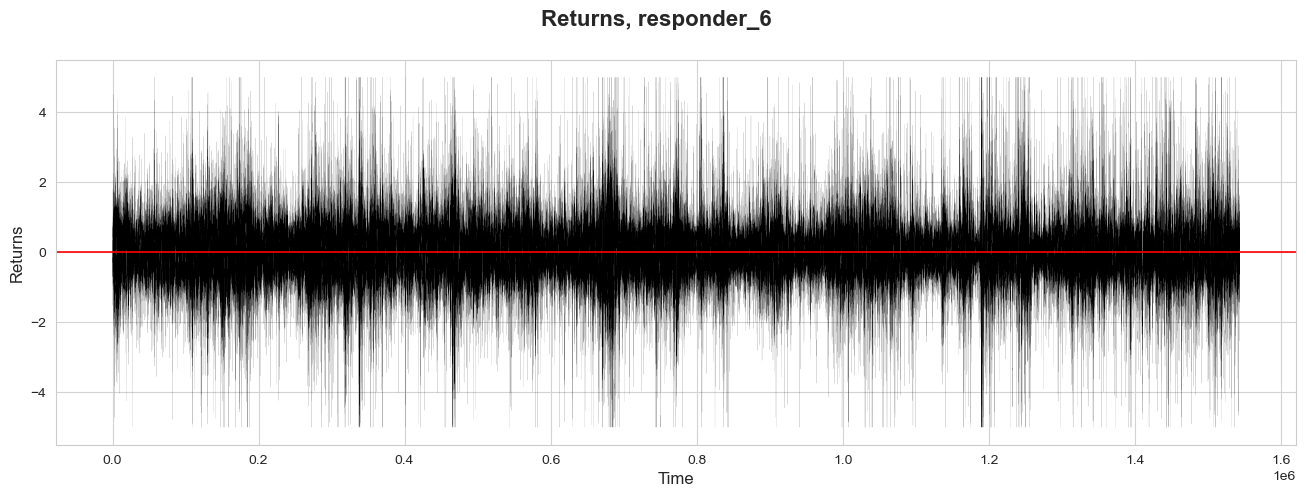

In [9]:
plt.figure(figsize=(16, 5))
plt.plot(yy, color = 'black', linewidth =0.05)
plt.suptitle('Returns, responder_6', weight='bold', fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Returns", fontsize=12)
plt.grid(color = 'lightgrey' , linewidth=0.8)
plt.axhline(0, color='red', linestyle='-', linewidth=1.2)
plt.show()

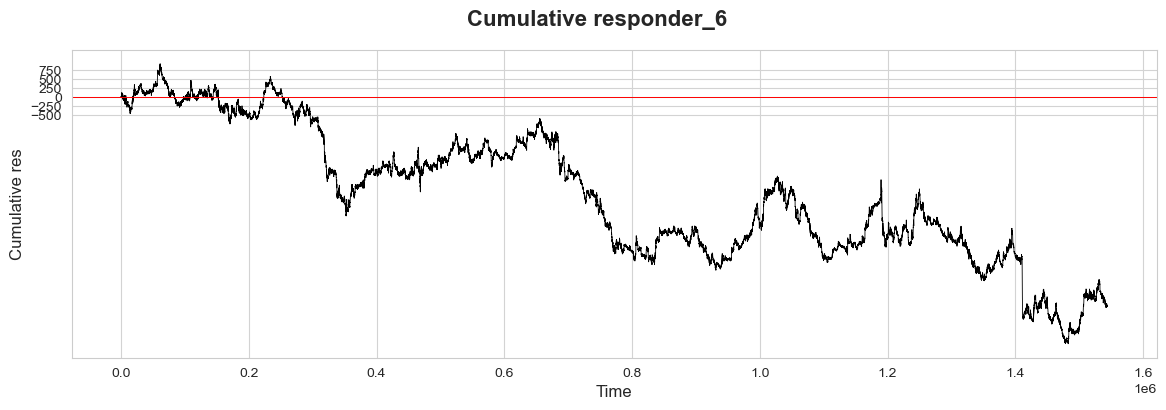

In [10]:
#for symbol_id=1, plot the cumulative sum of responder_6
plt.figure(figsize=(14, 4))
plt.plot(yy.select(pl.cum_sum("responder_6")), color = 'black', linewidth =0.6)
plt.suptitle('Cumulative responder_6', weight='bold', fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Cumulative res", fontsize=12)
plt.yticks(np.arange(-500,1000,250))
#plt.xticks(np.arange(0,170,10))
plt.grid(color = 'lightgrey')
#plt.grid(color = 'lightblue')
plt.axhline(0, color='red', linestyle='-', linewidth=0.7)
plt.show()

Similarly, we can plot the cumulative sum of responders for all the symbols.

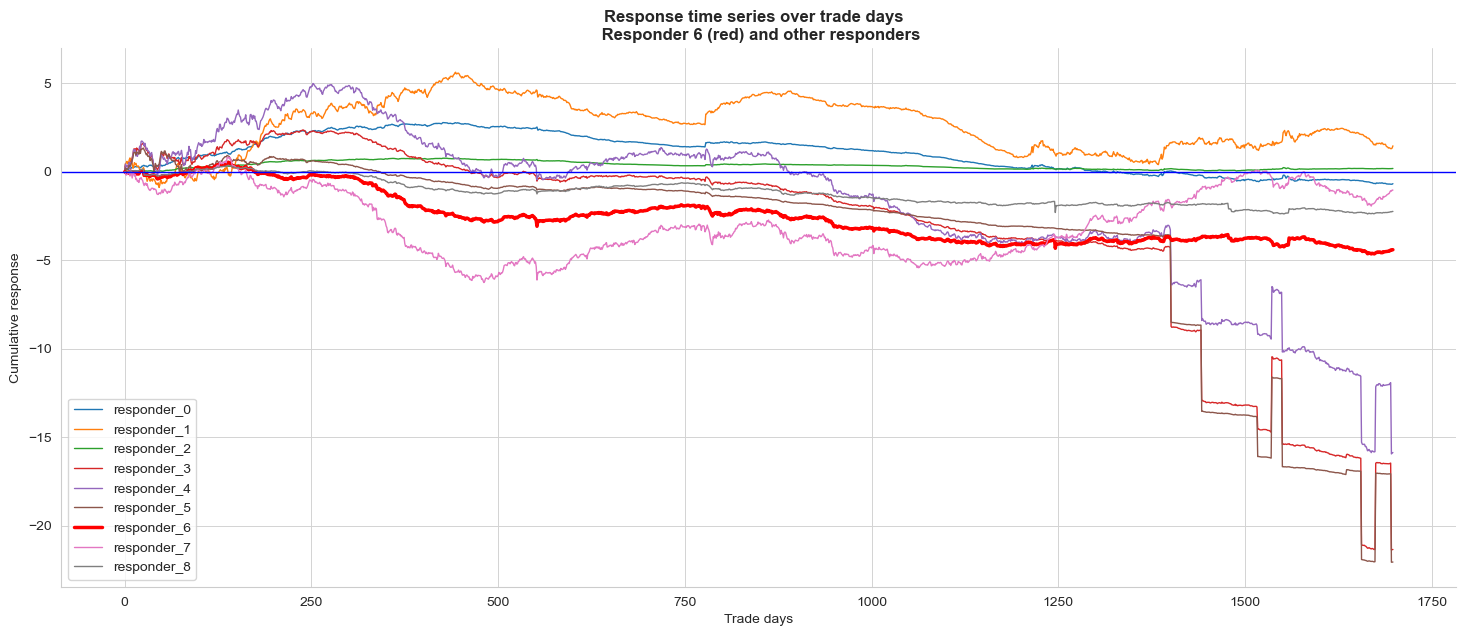

In [11]:
plt.figure(figsize=(18, 7))
#predictor_cols = [col for col in sample_df.columns if 'responder' in col]
predictor_cols = [ f"responder_{no}" for no in range(0,9,1) ]
for i in predictor_cols: 
    if i == 'responder_6': 
        c='red'
        lw=2.5
        resp = sample_df.group_by("date_id").agg(pl.col(f"{i}").mean().alias("responder_sum")) # calculate the average of the responder values for each date_id.
        resp = resp.sort('date_id')
    
        x = resp["date_id"].to_numpy()
        y = np.cumsum(resp['responder_sum'].to_numpy())
        plt.plot(x, y, linewidth = lw, color = c)
    else: 
        lw=1
        resp = sample_df.group_by("date_id").agg(pl.col(f"{i}").mean().alias("responder_sum"))
        resp = resp.sort('date_id')
    
        x = resp["date_id"].to_numpy()
        y = np.cumsum(resp['responder_sum'].to_numpy())
        plt.plot(x, y, linewidth = lw)

plt.xlabel('Trade days')
plt.ylabel('Cumulative response')
plt.title('Response time series over trade days  \n Responder 6 (red) and other responders', weight='bold')
plt.grid(visible=True, color = 'lightgrey', linewidth = 0.7)
plt.axhline(0, color='blue', linestyle='-', linewidth=1)
plt.legend(predictor_cols)
sns.despine()
#plt.show()

We can observe the highly negative trend of some responders. The one we would like to predict is the responder 6. 

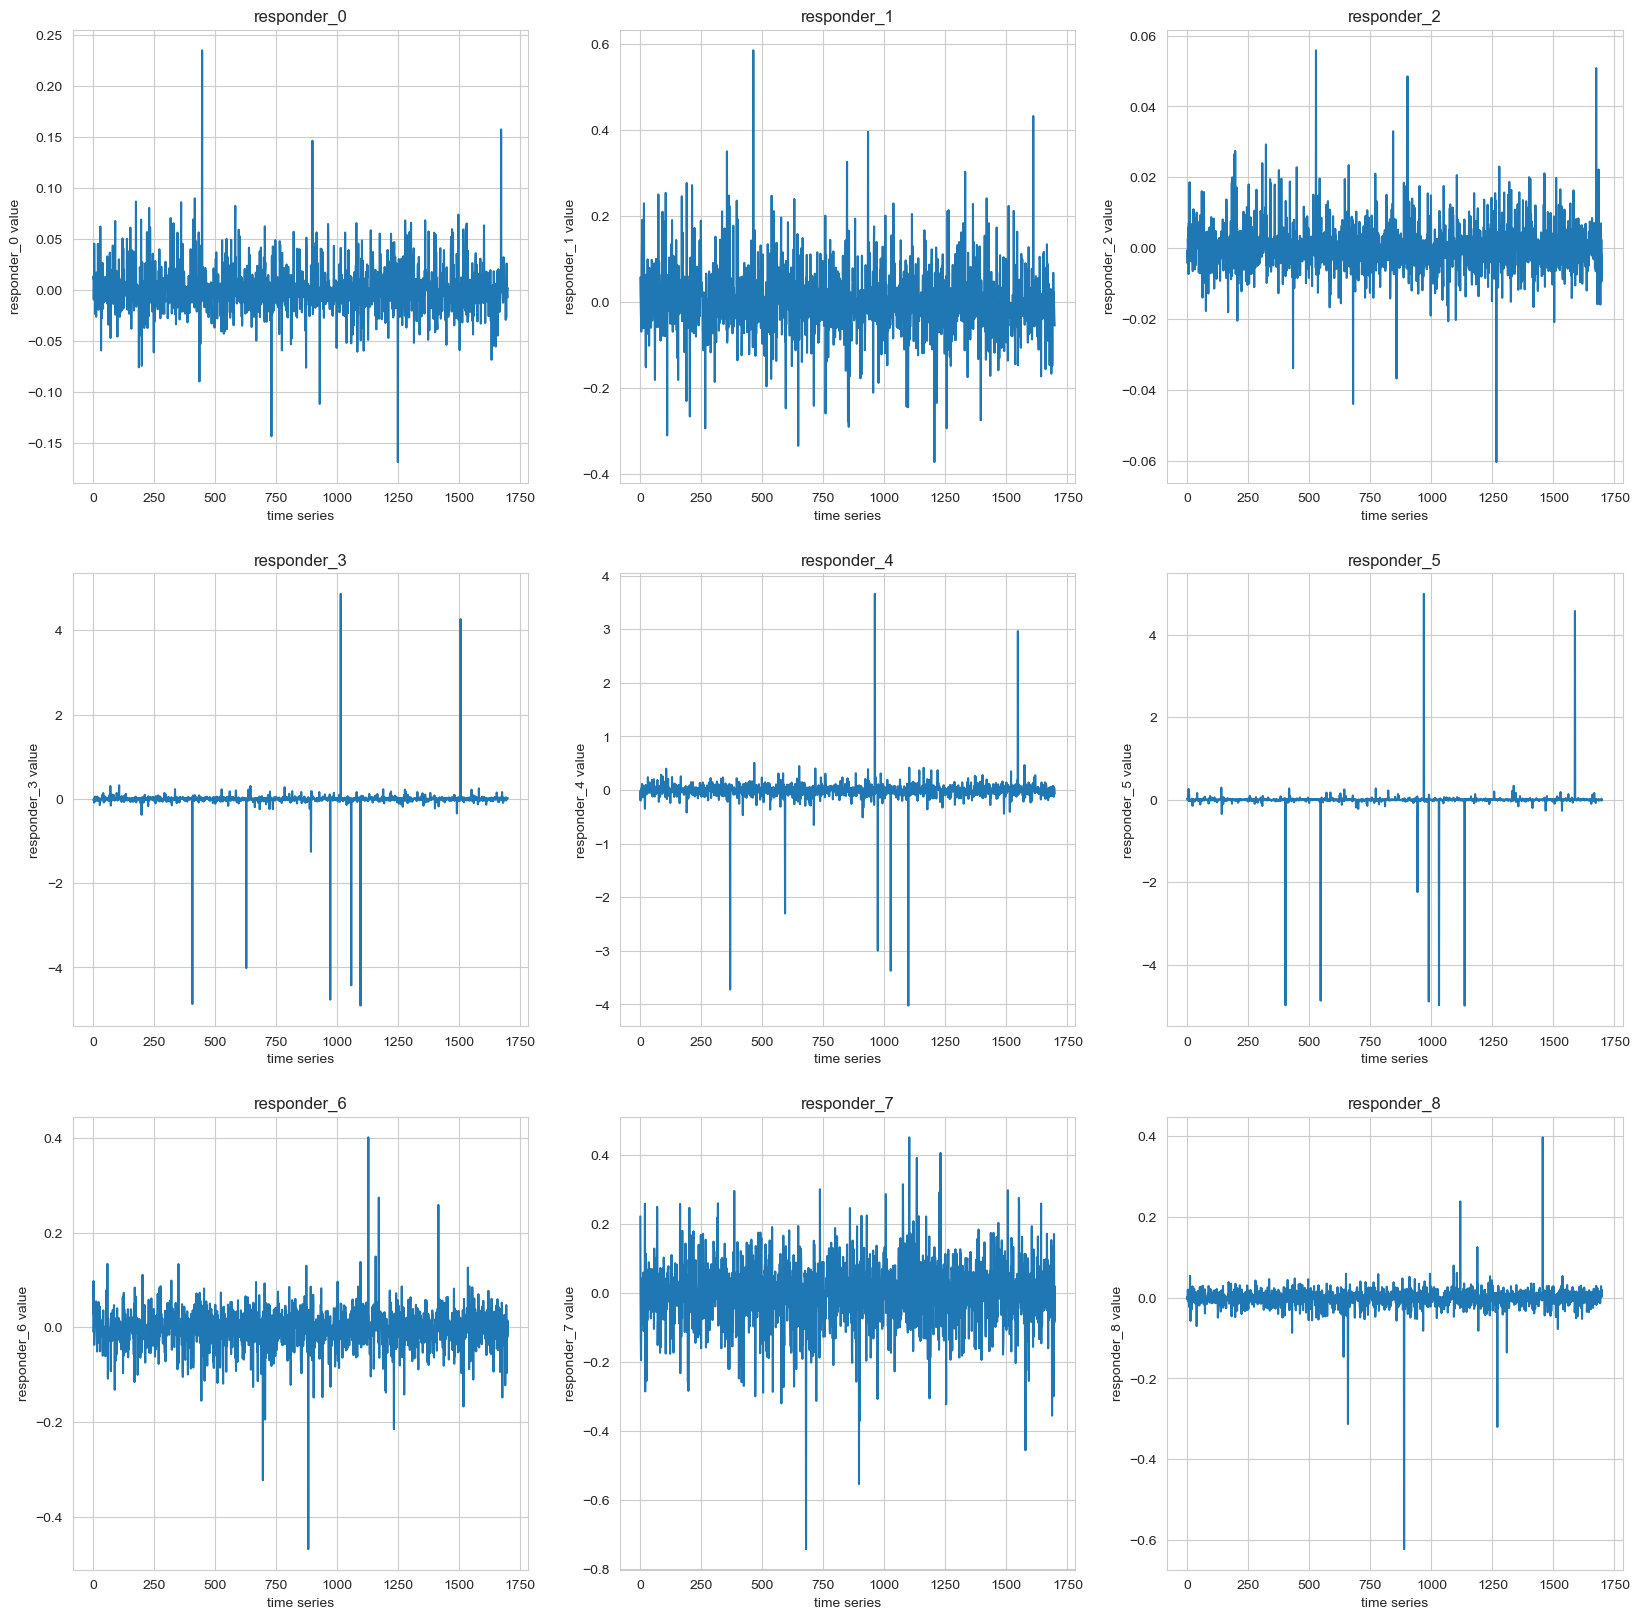

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(20, 20))
axes = axes.flatten()

for i in range(0,9):
    col_name = f'responder_{i}'
    resp = sample_df.group_by("date_id").agg(pl.col(f"responder_{i}").mean()) # calculate the average of the responder values for each date_id.
    axes[i].plot(resp[col_name])
    axes[i].set_title(col_name)  # Set title as the column name
    axes[i].grid(True)  # Add grid lines
    axes[i].set_xlabel("time series")  # Optional: Label for x-axis
    axes[i].set_ylabel(f"responder_{i} value") 

In [46]:
col =[]
for i in range(9):
    col.append(f"responder_{i}") 

sample_df.select(col).describe()

statistic,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",-0.001545,-0.000866,-0.000142,-0.01638,-0.012442,-0.016624,-0.002141,0.001476,-0.001114
"""std""",0.591211,0.587551,0.599179,0.819231,0.87284,0.734546,0.889852,0.916042,0.864412
"""min""",-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0
"""25%""",-0.19025,-0.163768,-0.199878,-0.310065,-0.383654,-0.225414,-0.382761,-0.419719,-0.334288
"""50%""",-0.004543,-0.023831,-0.000862,-0.025754,-0.04469,-0.009662,-0.025566,-0.039172,-0.008617
"""75%""",0.181948,0.127383,0.199062,0.261112,0.313263,0.200578,0.334321,0.355323,0.311202
"""max""",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


 Interesting fact:
- The values of all variables are strictly within the range of `[-5, 5]`

### Correlation matrix
Let's now calculate the correlation matrix of the responders. The correlation matrix is a table in which every cell contains a correlation coefficient, where 1 is considered a strong relationship between variables, 0 a neutral relationship and -1 an inverse relation, if a variable increases the other negative correlated decreases.

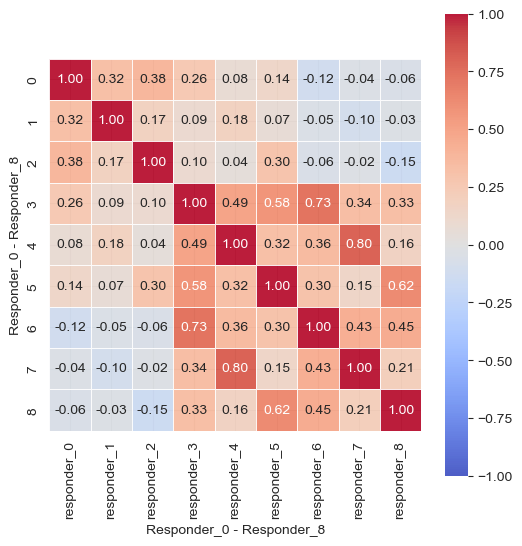

In [13]:
# select the responder columns and fill the null values with 0
responder_cols = [f"responder_{no}" for no in range(0, 9, 1)]
# calculate the correlation matrix
responders = sample_df.select(responder_cols).fill_null(0)
#responders = sample_df.select(responder_cols).drop_nans() # the outcome is the same

matrix_responders = responders.corr()
#matrix = sample_df.select(responder_cols).corr()

# convert Polars DataFrame to Pandas DataFrame for plotting the heatmap
matrix_pd = matrix_responders.to_pandas()

# plot the heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(matrix_pd, square=True, cmap="coolwarm", alpha=0.9, vmin=-1, vmax=1, center=0, linewidths=0.5, 
            linecolor='white', annot=True, fmt='.2f')
plt.xlabel("Responder_0 - Responder_8")
plt.ylabel("Responder_0 - Responder_8")
plt.show()

<font color=DodgerBlue>From the correlation matrix we can observe as responder 6 is strongly correlated for each time id with responder 3 and weakly with 0,1,2.

A proper model should therefore not only rely on the features but also on the other values of the responders.

In [14]:
# select  columns 
feature_cols = [f"feature_{no:02d}" for no in range(0, 79, 1)]
responder_cols = [f"responder_{no}" for no in range(0, 9, 1)]

all_cols = feature_cols + responder_cols

In [15]:
alls = sample_df.select(all_cols).drop_nans()
matrix_all = alls.corr()
# convert Polars DataFrame to Pandas DataFrame for plotting the heatmap
matrix_all_pd = matrix_all.to_pandas()

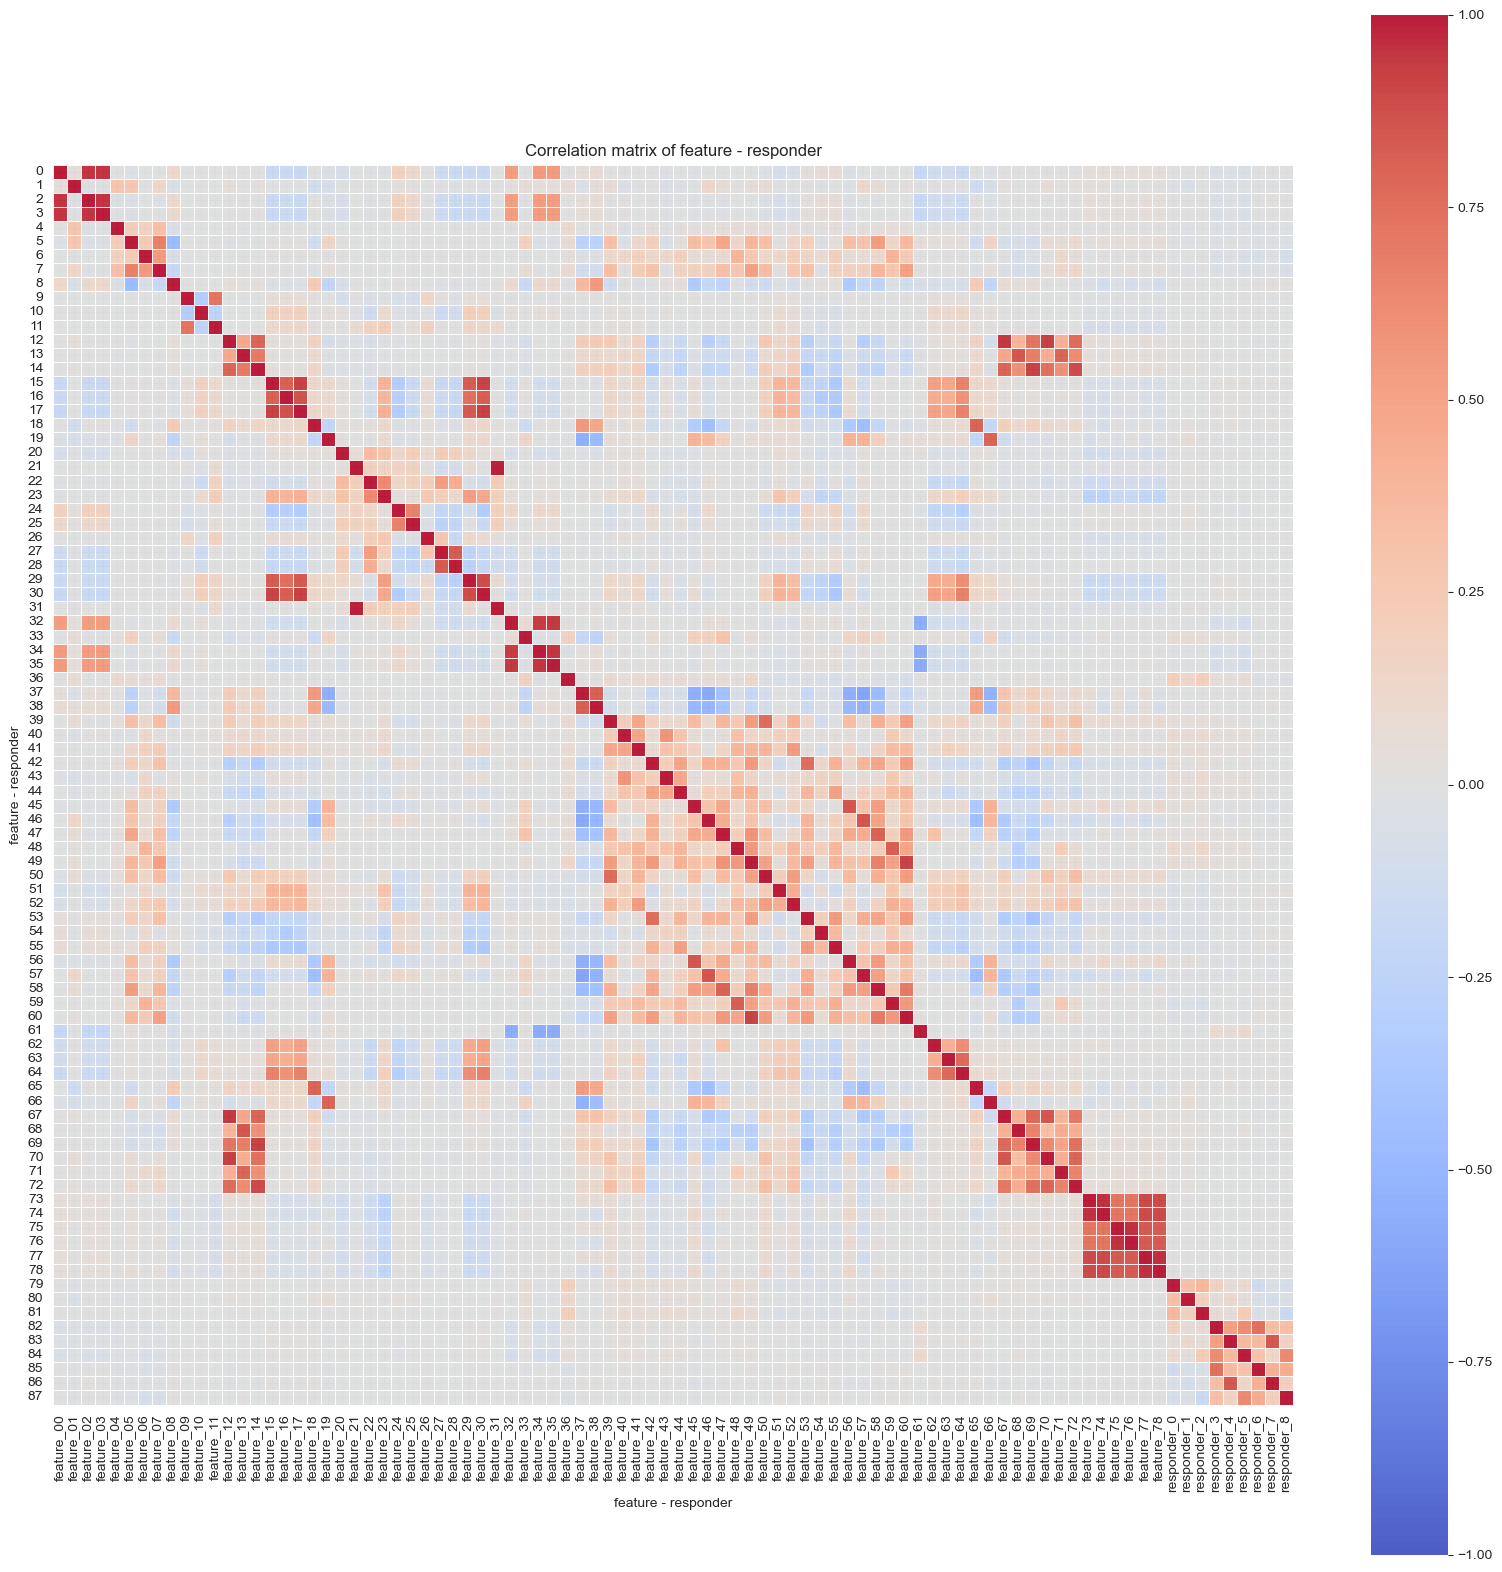

In [16]:
plt.figure(figsize=(20, 20))
sns.heatmap(matrix_all_pd, square=True, cmap="coolwarm", alpha=0.9, vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='white')
plt.xlabel("feature - responder")
plt.ylabel("feature - responder")
plt.title('Correlation matrix of feature - responder')
plt.show()

In [17]:
gc.collect()

33033

This correlation matrix shows the relationship between the features and the responders. The features are weakly **linear** correlated with the responders, which is expected since the features are anonymized. 

<font color=DodgerBlue>The Exploratory Data Analysis (EDA) of another file will, to some extent, reveal the reasons for correlations between features.

### Inspect the dates
Here we will inspect the dates and the time_id to understand the structure of the data.

In [18]:
train_time_id_max_df = (sample_df
             .group_by(pl.col("date_id"))
             .agg([pl.col("time_id").max().alias("max_time_id")])
             .sort("date_id"))

In [19]:
train_time_id_max_df

date_id,max_time_id
i16,i16
0,848
1,848
2,848
3,848
4,848
…,…
1694,967
1695,967
1696,967


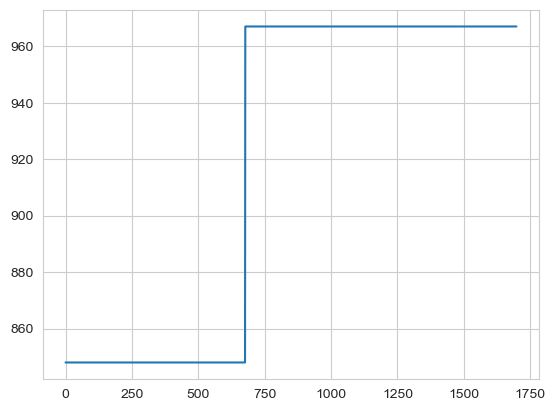

In [20]:
plt.plot(train_time_id_max_df["max_time_id"])

In [21]:
## This code is for the purpose of finding the date_id where the number of time_id changes
# compute the difference of "max_time_id"
diff_df = train_time_id_max_df.with_columns(pl.col("max_time_id").diff().alias("diff_max_time_id"))
# elect the rows where the difference is not zero
change_rows = diff_df.filter(pl.col("diff_max_time_id") != 0)
# extract the date_id where the difference is not zero
change_date_ids = change_rows.select("date_id")
change_date_ids

date_id
i16
677


From the graph and dataframe above we can observe that every day we have 849 time_id before the **date_id=677**. After this date id we have 968 time_id per day.

Next, we will inspect the number of symbols per day.

In [22]:
symbols_per_day = sample_df.group_by("date_id").agg([pl.col("symbol_id").n_unique().alias("nb_symbols")])
symbols_per_day = symbols_per_day.sort('date_id')

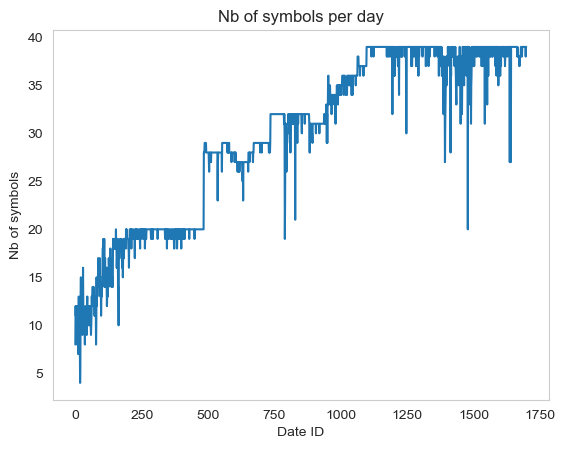

In [23]:
# concerning the symbols these are different 
# for every day with an increase for newer dates
x = symbols_per_day["date_id"].to_numpy()
y = symbols_per_day["nb_symbols"].to_numpy()

plt.plot(x, y)
plt.xlabel("Date ID")
plt.ylabel("Nb of symbols")
plt.title("Nb of symbols per day")
plt.grid()
plt.show()

As we can see from the chart, the number of symbols traded each day varies. Though the number of symbols traded each day is increasing over time, it still fluctuates.

### inspect nan
Due to the presence of certain missing values in the raw data, this section separately explores the data characteristics of various features and the responder for both the full sample and the period after 677 days.

In [24]:
sample_df

date_id,time_id,symbol_id,weight,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,…,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8,time_id_col,symbol_id_col
i16,i16,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i8,i8,i16,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i16,i8
0,0,1,3.889038,null,null,null,null,null,0.851033,0.242971,0.2634,-0.891687,11,7,76,-0.883028,0.003067,-0.744703,null,-0.169586,null,-1.335938,-1.707803,0.91013,null,1.636431,1.522133,-1.551398,-0.229627,null,null,1.378301,-0.283712,0.123196,null,null,…,null,-0.808103,null,-2.037683,0.727661,null,-0.989118,-0.345213,-1.36224,null,null,null,null,null,-1.251104,-0.110252,-0.491157,-1.02269,0.152241,-0.659864,null,null,-0.261412,-0.211486,-0.335556,-0.281498,0.738489,-0.069556,1.380875,2.005353,0.186018,1.218368,0.775981,0.346999,0.095504,0,1
0,0,7,1.370613,null,null,null,null,null,0.676961,0.151984,0.192465,-0.521729,11,7,76,-0.865307,-0.225629,-0.582163,null,0.317467,null,-1.250016,-1.682929,1.412757,null,0.520378,0.744132,-0.788658,0.641776,null,null,0.2272,0.580907,1.128879,null,null,…,null,-1.625862,null,-1.410017,1.063013,null,0.888355,0.467994,-1.36224,null,null,null,null,null,-1.065759,0.013322,-0.592855,-1.052685,-0.393726,-0.741603,null,null,-0.281207,-0.182894,-0.245565,-0.302441,2.965889,1.190077,-0.523998,3.849921,2.626981,5.0,0.703665,0.216683,0.778639,0,7
0,0,9,2.285698,null,null,null,null,null,1.056285,0.187227,0.249901,-0.77305,11,7,76,-0.675719,-0.199404,-0.586798,null,-0.814909,null,-1.296782,-2.040234,0.639589,null,1.597359,0.657514,-1.350148,0.364215,null,null,-0.017751,-0.317361,-0.122379,null,null,…,null,-0.72542,null,-2.29417,1.764551,null,-0.120789,-0.063458,-1.36224,null,null,null,null,null,-0.882604,-0.072482,-0.617934,-0.86323,-0.241892,-0.709919,null,null,0.377131,0.300724,-0.106842,-0.096792,-0.864488,-0.280303,-0.326697,0.375781,1.271291,0.099793,2.109352,0.670881,0.772828,0,9
0,0,10,0.690606,null,null,null,null,null,1.139366,0.273328,0.306549,-1.262223,42,5,150,-0.694008,3.004091,0.114809,null,-0.251882,null,-1.902009,-0.979447,0.241165,null,-0.392359,-0.224699,-2.129397,-0.855287,null,null,0.404142,-0.578156,0.105702,null,null,…,null,1.313203,null,-0.810125,2.939022,null,3.988801,1.834661,-1.36224,null,null,null,null,null,-0.697595,1.074309,-0.206929,-0.530602,4.765215,0.571554,null,null,-0.226891,-0.251412,-0.215522,-0.296244,0.408499,0.223992,2.294888,1.097444,1.225872,1.225376,1.114137,0.775199,-1.379516,0,10
0,0,14,0.44057,null,null,null,null,null,0.9552,0.262404,0.344457,-0.613813,44,3,16,-0.947351,-0.030018,-0.502379,null,0.646086,null,-1.844685,-1.58656,-0.182024,null,-0.969949,-0.673813,-1.282132,-1.399894,null,null,0.043815,-0.320225,-0.031713,null,null,…,null,0.476195,null,-0.771732,2.843421,null,1.379815,0.411827,-1.36224,null,null,null,null,null,-0.948601,-0.136814,-0.447704,-1.141761,0.099631,-0.661928,null,null,3.678076,2.793581,2.61825,3.418133,-0.373387,-0.502764,-0.348021,-3.928148,-1.591366,-5.0,-3.57282,-1.089123,-5.0,0,14
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1698,967,34,3.24249

In [25]:
# compute percentage of nans per column
sample_df.select([
    (((pl.col(col).is_nan() | pl.col(col).is_null()).sum() / len(sample_df)).alias(col)) for col in sample_df.columns
])

date_id,time_id,symbol_id,weight,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,…,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8,time_id_col,symbol_id_col
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.06752,0.06752,0.06752,0.06752,0.06752,0.0,0.0,0.0,0.006371,0.0,0.0,0.0,0.0,0.0,0.0,0.02566,0.000006,0.004283,0.000005,0.000005,0.0,0.179004,0.0,0.0,0.0,0.0,0.179004,0.179004,0.0,0.0,0.0,0.179004,0.010152,…,0.090268,0.000293,0.022172,0.000005,0.000005,0.010152,0.0,0.0,0.0,0.006214,0.004829,0.005043,0.00673,0.00673,0.0,0.0,0.0,0.0,0.0,0.0,0.010265,0.010265,0.00124,0.00124,0.000425,0.000425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
## For the whole dataset

# Initialize an empty DataFrame with a predefined schema
initial_schema = {
    "column": pl.Utf8,
    'unique':pl.Boolean,
    "cardinality": pl.Int64,
    "with_null": pl.Boolean,
    "null_pct": pl.Float64,
    "1st_row": pl.Float64,
    "last_row": pl.Float64,
    "dtype": pl.Utf8
}

stats_df = pl.DataFrame(schema=initial_schema)

for col in sample_df.columns:
    # Calculate the number of unique values in the column
    unique_count = sample_df[col].n_unique()
    
    # is_unique
    is_unique = unique_count == sample_df.height
    
    # Check if the column contains null values
    with_null = sample_df[col].is_null().sum() > 0
    
    # Calculate the percentage of null values
    null_pct = (sample_df[col].is_null().sum() / sample_df.height) * 100
    #null_pct = pl.lit(null_pct).cast(pl.Float32)
    
    # get the first value of the column, if it is null then use 0.0 as default
    first_row = sample_df[col].first()
    if first_row is None:
        first_row = 0.0
    else:
        first_row = float(first_row)
    
    # get the last value of the column, if it is null then use 0.0 as default
    last_row = sample_df[col].last()
    if last_row is None:
        last_row = 0.0
    else:
        last_row = float(last_row)
    
    # Get the data type of the column
    dtype = str(sample_df[col].dtype)
    
    # Create a new row with the calculated statistics
    new_data = pl.DataFrame({
        "column": [col],
        'unique':[is_unique],
        "cardinality": [unique_count],
        "with_null": [with_null],
        "null_pct": [null_pct],
        "1st_row": [first_row],
        "last_row": [last_row],
        "dtype": [dtype]
    })
    
    # Append statistics to the DataFrame
    stats_df = stats_df.vstack(new_data)

stats_df


column,unique,cardinality,with_null,null_pct,1st_row,last_row,dtype
str,bool,i64,bool,f64,f64,f64,str
"""date_id""",false,1699,false,0.0,0.0,1698.0,"""Int16"""
"""time_id""",false,968,false,0.0,0.0,967.0,"""Int16"""
"""symbol_id""",false,39,false,0.0,1.0,38.0,"""Int8"""
"""weight""",false,50341,false,0.0,3.889038,3.193685,"""Float32"""
"""feature_00""",false,33358770,true,6.75203,0.0,2.728506,"""Float32"""
…,…,…,…,…,…,…,…
"""responder_6""",false,37372542,false,0.0,0.775981,-0.138548,"""Float32"""
"""responder_7""",false,37232319,false,0.0,0.346999,-0.038771,"""Float32"""
"""responder_8""",false,37699573,false,0.0,0.095504,-0.21194,"""Float32"""


As we can see in the table above, the features have many missing values. 
For example ,`feature_00` to `feature_04`,  have the same percentage of missing values, so do `feature_20`, `feature_26`, `feature_27`, and `feature_31`. This might relate to their components, which I will explore in the next section.

On the other hand, The columns `responder_0` to `responder_8` have no missing values.

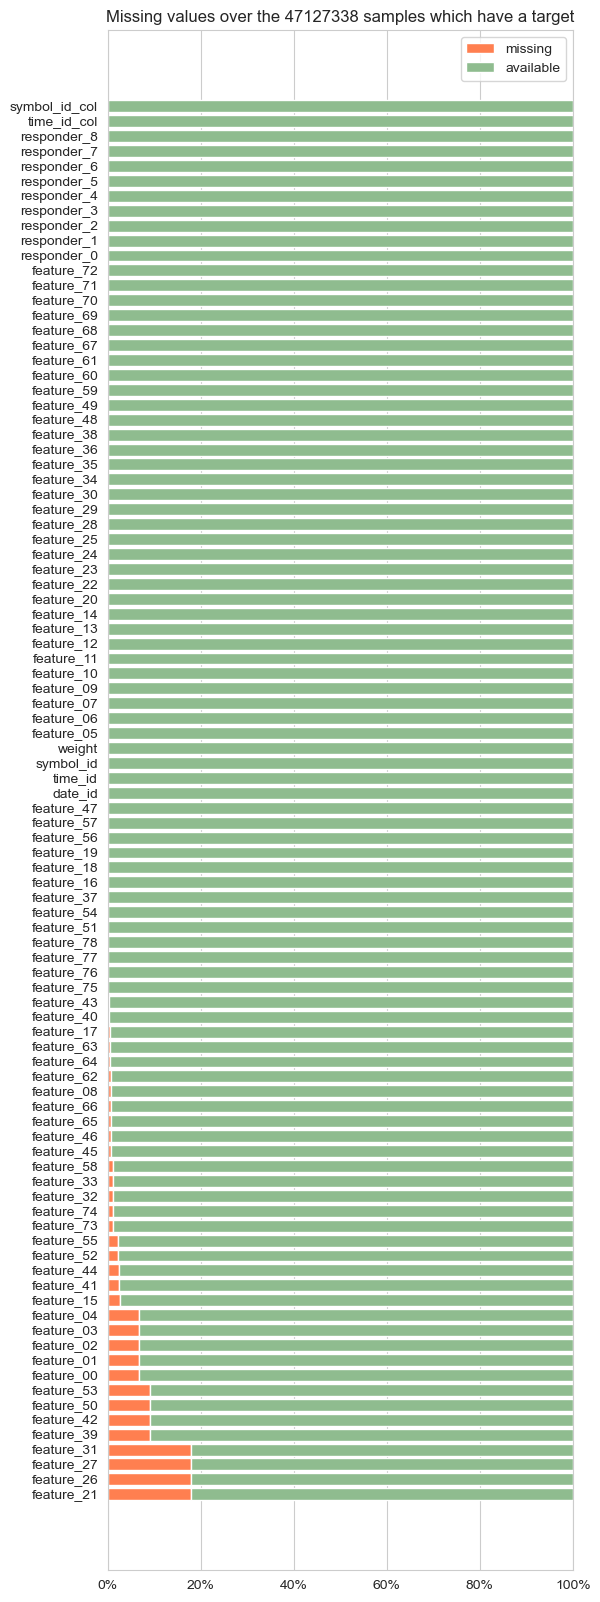

In [27]:
## for the whole dataset
supervised_usable = (
    sample_df
)

missing_count = (
    supervised_usable
    .null_count()
    .transpose(include_header=True,
               header_name='feature',
               column_names=['null_count'])
    .sort('null_count', descending=True)
    .with_columns((pl.col('null_count') / len(supervised_usable)).alias('null_ratio'))
)

plt.figure(figsize=(6, 20))
plt.title(f'Missing values over the {len(supervised_usable)} samples which have a target')
plt.barh(np.arange(len(missing_count)), missing_count.get_column('null_ratio'), color='coral', label='missing')
plt.barh(np.arange(len(missing_count)), 
         1 - missing_count.get_column('null_ratio'),
         left=missing_count.get_column('null_ratio'),
         color='darkseagreen', label='available')
plt.yticks(np.arange(len(missing_count)), missing_count.get_column('feature'))
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
plt.xlim(0, 1)
plt.legend()
plt.show()

To better visualize the data, the proportion of missing data can be plotted in a chart.
- It can be observed that within the full sample, feature_20, feature_26, feature_27, and feature_31 have the highest proportion of missing values.

Next, we will inspect the missing values for the period after 677 days.

In [28]:
## For the period after 677 days

# Initialize an empty DataFrame with a predefined schema
initial_schema = {
    "column": pl.Utf8,
    'unique':pl.Boolean,
    "cardinality": pl.Int64,
    "with_null": pl.Boolean,
    "null_pct": pl.Float64,
    "1st_row": pl.Float64,
    "last_row": pl.Float64,
    "dtype": pl.Utf8
}

stats_df_677 = pl.DataFrame(schema=initial_schema)

sample_df_677 = sample_df.filter(pl.col("date_id") > 677) # filter the data after date_id=677

for col in sample_df_677.columns:
    # Calculate the number of unique values in the column
    unique_count = sample_df_677[col].n_unique()
    
    # is_unique
    is_unique = unique_count == sample_df_677.height
    
    # Check if the column contains null values
    with_null = sample_df_677[col].is_null().sum() > 0
    
    # Calculate the percentage of null values
    null_pct = (sample_df_677[col].is_null().sum() / sample_df_677.height) * 100
    #null_pct = pl.lit(null_pct).cast(pl.Float32)
    
    first_row = sample_df_677[col].first()
    if first_row is None:
        first_row = 0.0
    else:
        first_row = float(first_row)
    
    last_row = sample_df_677[col].last()
    if last_row is None:
        last_row = 0.0
    else:
        last_row = float(last_row)
    
    # Get the data type of the column
    dtype = str(sample_df_677[col].dtype)
    
    # Create a new row with the calculated statistics
    new_data = pl.DataFrame({
        "column": [col],
        'unique':[is_unique],
        "cardinality": [unique_count],
        "with_null": [with_null],
        "null_pct": [null_pct],
        "1st_row": [first_row],
        "last_row": [last_row],
        "dtype": [dtype]
    })
    
    # Append statistics to the DataFrame
    stats_df_677 = stats_df_677.vstack(new_data)

stats_df_677


column,unique,cardinality,with_null,null_pct,1st_row,last_row,dtype
str,bool,i64,bool,f64,f64,f64,str
"""date_id""",false,1021,false,0.0,678.0,1698.0,"""Int16"""
"""time_id""",false,968,false,0.0,0.0,967.0,"""Int16"""
"""symbol_id""",false,39,false,0.0,0.0,38.0,"""Int8"""
"""weight""",false,36527,false,0.0,2.237853,3.193685,"""Float32"""
"""feature_00""",false,28223319,false,0.0,-0.188799,2.728506,"""Float32"""
…,…,…,…,…,…,…,…
"""responder_6""",false,29591631,false,0.0,1.187268,-0.138548,"""Float32"""
"""responder_7""",false,29492479,false,0.0,0.615022,-0.038771,"""Float32"""
"""responder_8""",false,29759403,false,0.0,0.744489,-0.21194,"""Float32"""


It can be observed that after 677 days (i.e., following the change in the number of time_id), there is a significant reduction in the missing values in the data, indicating that a large number of missing values occurred predominantly in the earlier data.

Additionally, it is worth emphasizing that by examining the above two tables, we can observe that **`weight` is a daily frequency data point.** This means that for each symbol, there will only be one weight per day, which does not vary with `time_id`.

### Weights
Next, we will inspect the weights of the symbols.
As we can see in the website, the weights are used for calculating the scoring function:

''
Submissions are evaluated on a scoring function defined as the sample weighted zero-mean R-squared score (R²) of `responder_6`. The formula is given by:

$ R^2 = 1 - \frac{\sum w_i (y_i - \hat{y}_i)^2}{\sum w_i y_i^2}, $

where $ y $ and $ \hat{y} $ are the ground-truth and predicted value vectors of `responder_6`, respectively; $ w $ is the sample weight vector.
''


In [39]:
sample_df.select(
    pl.col('weight')
).describe()

statistic,weight
str,f64
"""count""",4.7127338e7
"""null_count""",0.0
"""mean""",2.009445
"""std""",1.129388
"""min""",0.149967
"""25%""",1.210248
"""50%""",1.749686
"""75%""",2.525645
"""max""",10.240419


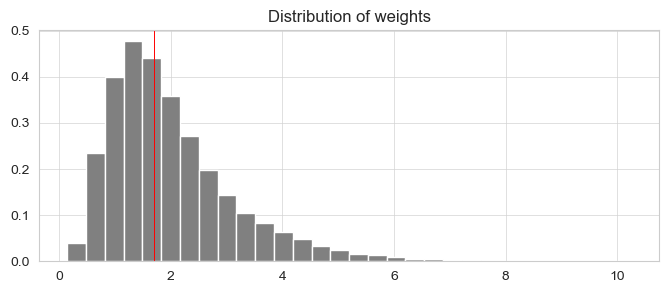

In [40]:
# inspect the distribution of the weights
plt.figure(figsize=(8,3))
plt.hist(sample_df.select('weight'), bins=30, color='grey', edgecolor = 'white',density=True )
plt.title('Distribution of weights')
plt.grid(color = 'lightgrey', linewidth=0.5)
plt.axvline(1.7, color='red', linestyle='-', linewidth=0.7)
plt.show()

Nwo, for the full sample of 39 `symbol_id`, a plot illustrating how `weight` changes with `date_id` is created for each one.

In [41]:
# Plot axes styler:-
myaxesstyle = \
{'axes.facecolor'   : 'white',
 'axes.edgecolor'   : 'black',
 'axes.grid'        : False,
 'axes.axisbelow'   : True,
 'axes.labelcolor'  : '.15',
 'figure.facecolor' : 'white',
 'grid.color'       : 'white',
 'grid.linestyle'   : '-',
 'patch.edgecolor'  : 'white',
 'figure.facecolor' : 'white',
}

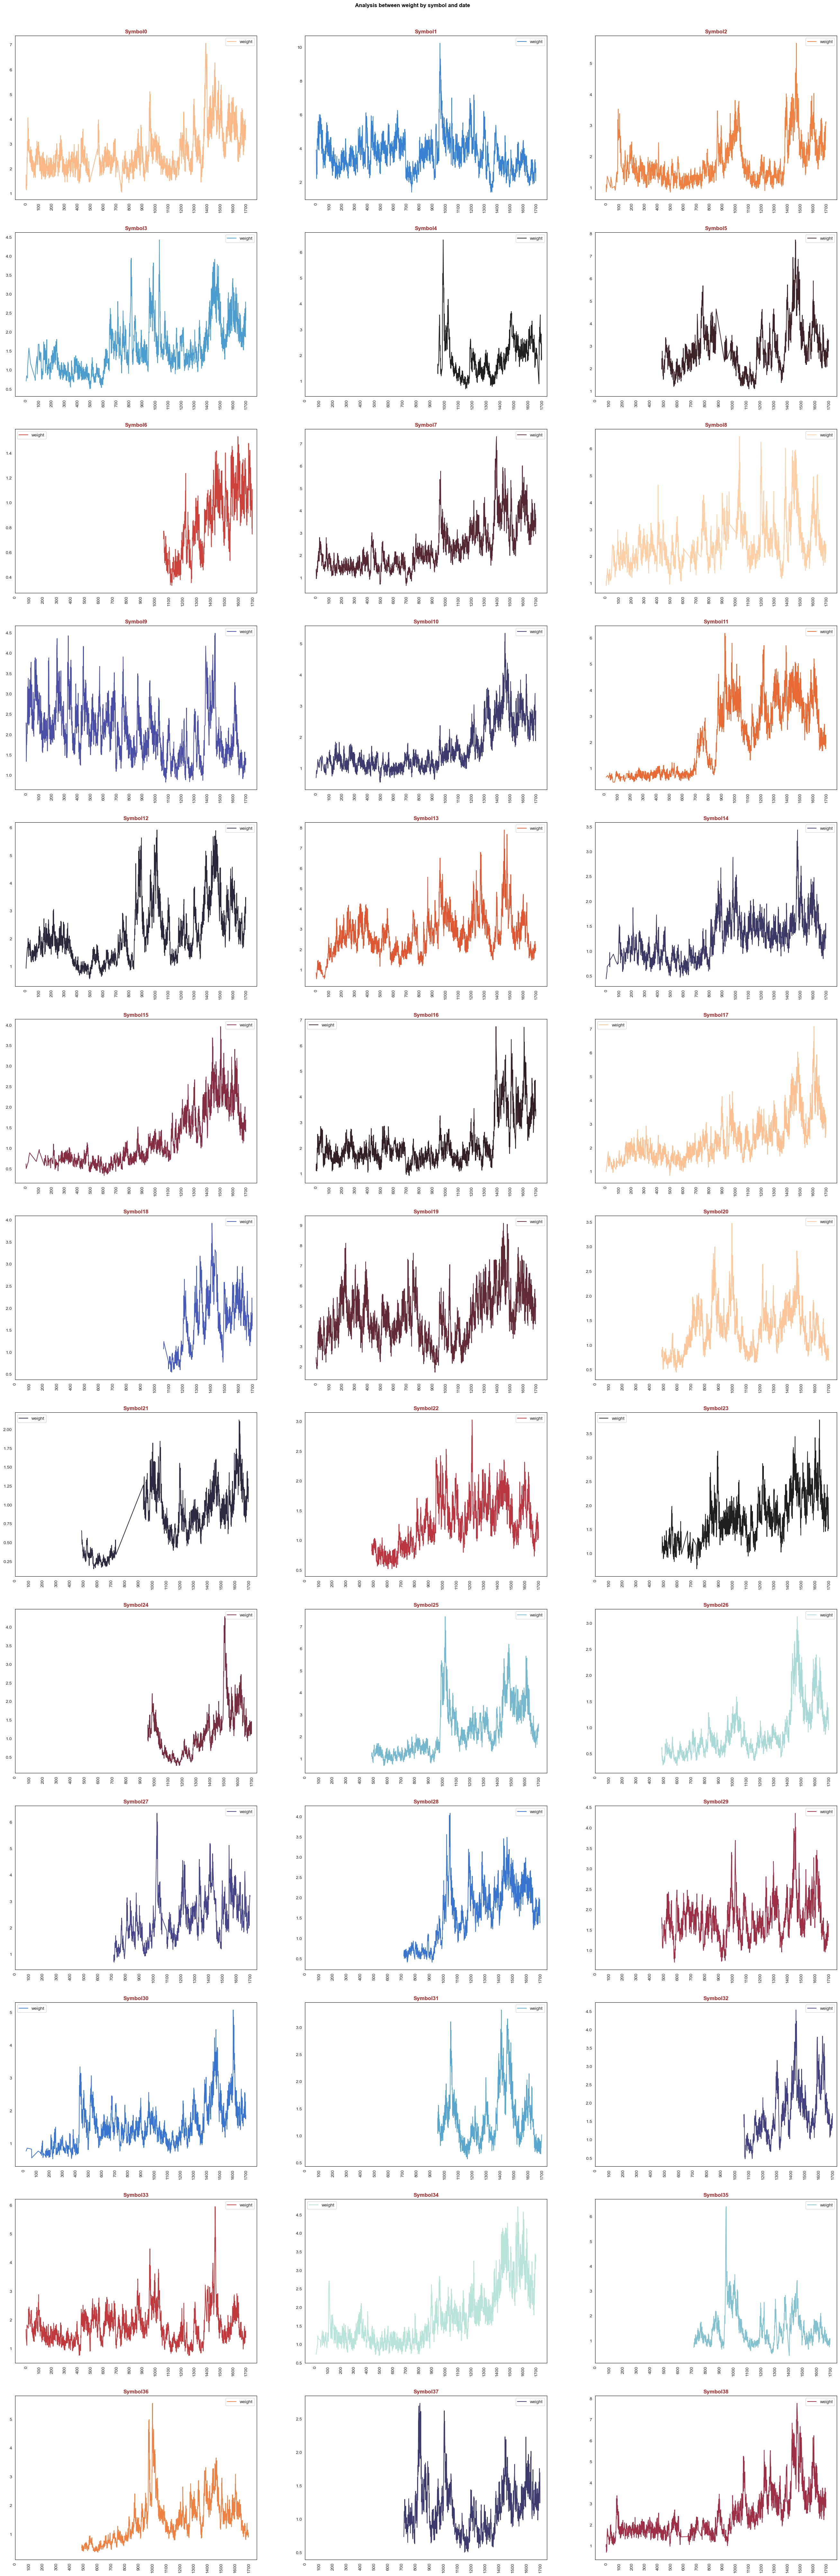

In [42]:
with sns.axes_style(myaxesstyle):
    df = \
    pl.sql(
        """
        SELECT date_id, symbol_id, weight, count(date_id) as num_rcrds
        FROM sample_df
        group by date_id, symbol_id, weight 
        order by date_id, symbol_id, weight 
        """
    )
    all_colors = sns.color_palette("icefire", n_colors = 100,)
    
    fig, axes = \
    plt.subplots(13, 3, figsize = (33, 102), 
                 gridspec_kw = {"hspace" : 0.2, "wspace" : 0.2}
                )
    for i in range(39):
        ax = axes[i//3, i % 3]
        j  = np.random.randint(0, 100,)
        
        (df.
         filter(pl.col("symbol_id").eq(i)).
         select(["date_id", "weight"]).
         collect().
         to_pandas().
         set_index("date_id").
         plot.line(ax = ax, color = all_colors[j])
        )
        ax.set_title(f"Symbol{i}", **{"fontweight" : 900, "color" : "brown"})
        ax.set(xlabel = "")
        ax.set_xticks(
            range(0, 1701, 100), labels = range(0, 1701, 100), rotation = 90
        )
        
    plt.suptitle(
        f"Analysis between weight by symbol and date", 
        y = 0.89, 
        **{"fontweight" : 900, "color" : "black"}
    )
    plt.tight_layout()
    plt.show()

From the above plots, we can make the following observations:

- The `weight` of each `symbol` changes as the `date` progresses.
- Some `symbols` did not have data for earlier dates, which is consistent with the previous `Nb of symbols per day` plot.

## File2: lag

 Values of responder_{0...8} lagged by one date_id. The evaluation API serves the entirety of the lagged responders for a date_id on that date_id's first time_id. In other words, all of the previous date's responders will be served at the first time step of the succeeding date.

In [29]:
lag_sample = pl.read_parquet('data/lags.parquet/date_id=0/part-0.parquet')
lag_sample

date_id,time_id,symbol_id,responder_0_lag_1,responder_1_lag_1,responder_2_lag_1,responder_3_lag_1,responder_4_lag_1,responder_5_lag_1,responder_6_lag_1,responder_7_lag_1,responder_8_lag_1
i16,i16,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32
0,0,0,-0.442215,-0.322407,0.143594,-0.92689,-0.782236,-0.036595,-1.305746,-0.795677,-0.143724
0,0,1,-0.651829,-1.70784,-0.893942,-1.065488,-1.871338,-0.615652,-1.162801,-1.205924,-1.245934
0,0,2,-0.656373,-0.264575,-0.892879,-1.511886,-1.03348,-0.378265,-1.57429,-1.863071,-0.027343
0,0,3,-0.188186,-0.19097,-0.70149,0.098453,-1.015506,-0.054984,0.329152,-0.965471,0.576635
0,0,4,-0.257462,-0.471325,-0.29742,0.074018,-0.324194,-0.597093,0.219856,-0.276356,-0.90479
…,…,…,…,…,…,…,…,…,…,…,…
0,0,34,-0.185392,-0.187891,-0.206658,-0.634903,-0.643175,-0.443875,-0.556474,-1.122211,-0.884185
0,0,35,-0.308923,-0.434147,-1.354941,0.30054,-0.830827,0.424937,0.518839,-0.687369,1.440577
0,0,36,-0.074661,-0.261698,-0.007051,-2.60039,-1.146709,-1.601274,-3.216254,-1.249338,-2.868875


## File3: Test dataset¶
A mock test set which represents the structure of the unseen test set. This example set demonstrates a single batch served by the evaluation API, that is, data from a single date_id, time_id pair. The test set contains columns including date_id, time_id, symbol_id, weight, is_scored, and feature_{00...78}. You will not be directly using the test set or sample submission in this competition, as the evaluation API will get/set the test set and predictions.

In [30]:
test_path = 'data/test.parquet/date_id=0/part-0.parquet'
test_pl = pl.read_parquet(test_path)

In [31]:
test_pl.shape

(39, 85)

In [32]:
test_pl

row_id,date_id,time_id,symbol_id,weight,is_scored,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,…,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78
i64,i16,i16,i8,f32,bool,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
0,0,0,0,3.169998,true,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,null,-0.0,null,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,…,null,-0.0,null,-0.0,0.0,-0.0,0.0,0.0,null,0.0,null,null,-0.0,null,-0.0,0.0,null,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,null,null,0.0,0.0,-0.0,-0.0
1,0,0,1,2.165993,true,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,null,-0.0,null,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,…,null,-0.0,null,-0.0,0.0,0.0,0.0,0.0,null,0.0,null,null,-0.0,null,-0.0,0.0,null,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,null,null,0.0,0.0,0.0,0.0
2,0,0,2,3.06555,true,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,null,-0.0,null,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,…,null,-0.0,null,-0.0,0.0,-0.0,-0.0,-0.0,null,0.0,null,null,-0.0,null,-0.0,0.0,null,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,null,null,0.0,0.0,-0.0,-0.0
3,0,0,3,2.698642,true,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,null,-0.0,null,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,…,null,-0.0,null,-0.0,0.0,-0.0,0.0,-0.0,null,-0.0,null,null,-0.0,null,-0.0,0.0,null,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,null,null,0.0,0.0,-0.0,-0.0
4,0,0,4,1.80333,true,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,null,-0.0,null,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,…,null,-0.0,null,-0.0,0.0,0.0,0.0,0.0,null,0.0,null,null,-0.0,null,-0.0,0.0,null,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,null,null,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
34,0,0,34,3.240565,true,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,null,-0.0,null,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,…,null,-0.0,null,-0.0,-0.0,-0.0,-0.0,-0.0,null,-0.0,null,null,-0.0,null,-0.0,-0.0,null,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,null,null,0.0,0.0,0.0,0.0
35,0,0,35,1.057221,true,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,null,-0.0,null,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,…,null,0.0,null,-0.0,0.0,0.0,0.0,0.0,null,0.0,null,null,0.0,null,-0.0,0.0,null,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,null,null,0.0,0.0,-0.0,-0.0
36,0,0,36,0.907022,true,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,null,-0.0,null,-0.0,-0.0,-0.0,null,-0.0,-0.0,0.0,-0.0,null,null,-0.0,-0.0,-0.0,…,null,-0.0,null,-0.0,0.0,-0.0,0.0,0.0,null,0.0,null,null,0.0,null,-0.0,0.0,null,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,null,null,0.0,0.0,0.0,0.0


In [33]:
print(test_pl.columns)

['row_id', 'date_id', 'time_id', 'symbol_id', 'weight', 'is_scored', 'feature_00', 'feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'featur

The test set doesn't contain all the columns that are inside the train set. Indeed it represents as the data will be served at inference time. Data about the responders will be provided in a separete dataframe lags.parquet as explained in the previous section.


## File4: Features.csv
features.csv - metadata pertaining to the anonymized features

In [34]:
features = pd.read_csv(f"data/features.csv")
features

,feature,tag_0,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,tag_9,tag_10,tag_11,tag_12,tag_13,tag_14,tag_15,tag_16
0,feature_00,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True
1,feature_01,False,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False,True
2,feature_02,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True
3,feature_03,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
4,feature_04,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,feature_74,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
75,feature_75,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
76,feature_76,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
77,feature_77,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False


Here, I will plot the features and tags to understand the structure of the data.

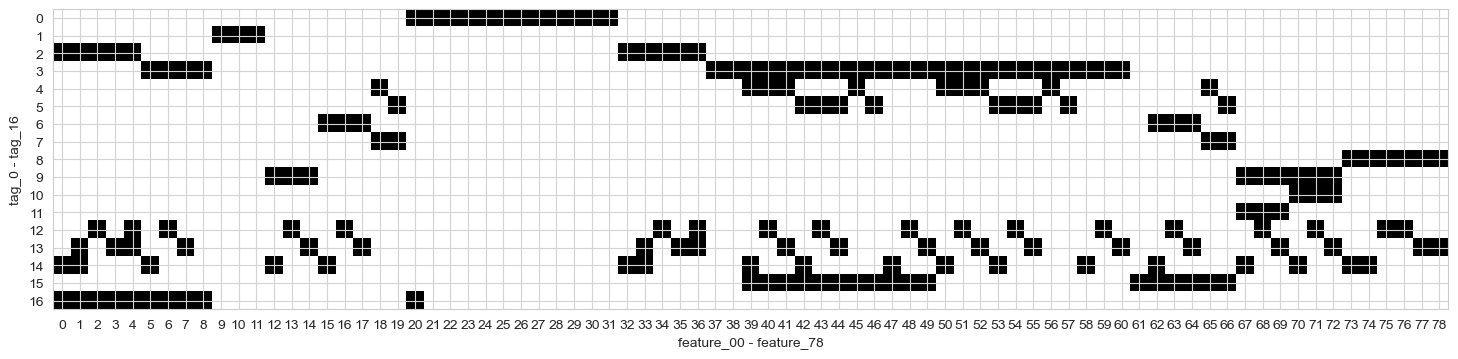

In [35]:
plt.figure(figsize=(18, 6))
plt.imshow(features.iloc[:, 1:].T.values, cmap="gray_r")
plt.xlabel("feature_00 - feature_78")
plt.ylabel("tag_0 - tag_16")
plt.yticks(np.arange(17))
plt.xticks(np.arange(79))
plt.grid(color = 'lightgrey')
plt.show()

This figure can be used to understand the structure of the data. Based on this chart, we can make the following inferences:
- There are 17 tags which might be used to form a group of features.
- Each feature is associated with more than one tag.

Hence, recalling the correlation matrix of the features and responders that I computed earlier, we can propose the following hypothesis:

<font color=red>The high correlation between features is likely attributable to the use of similar tags.</font>


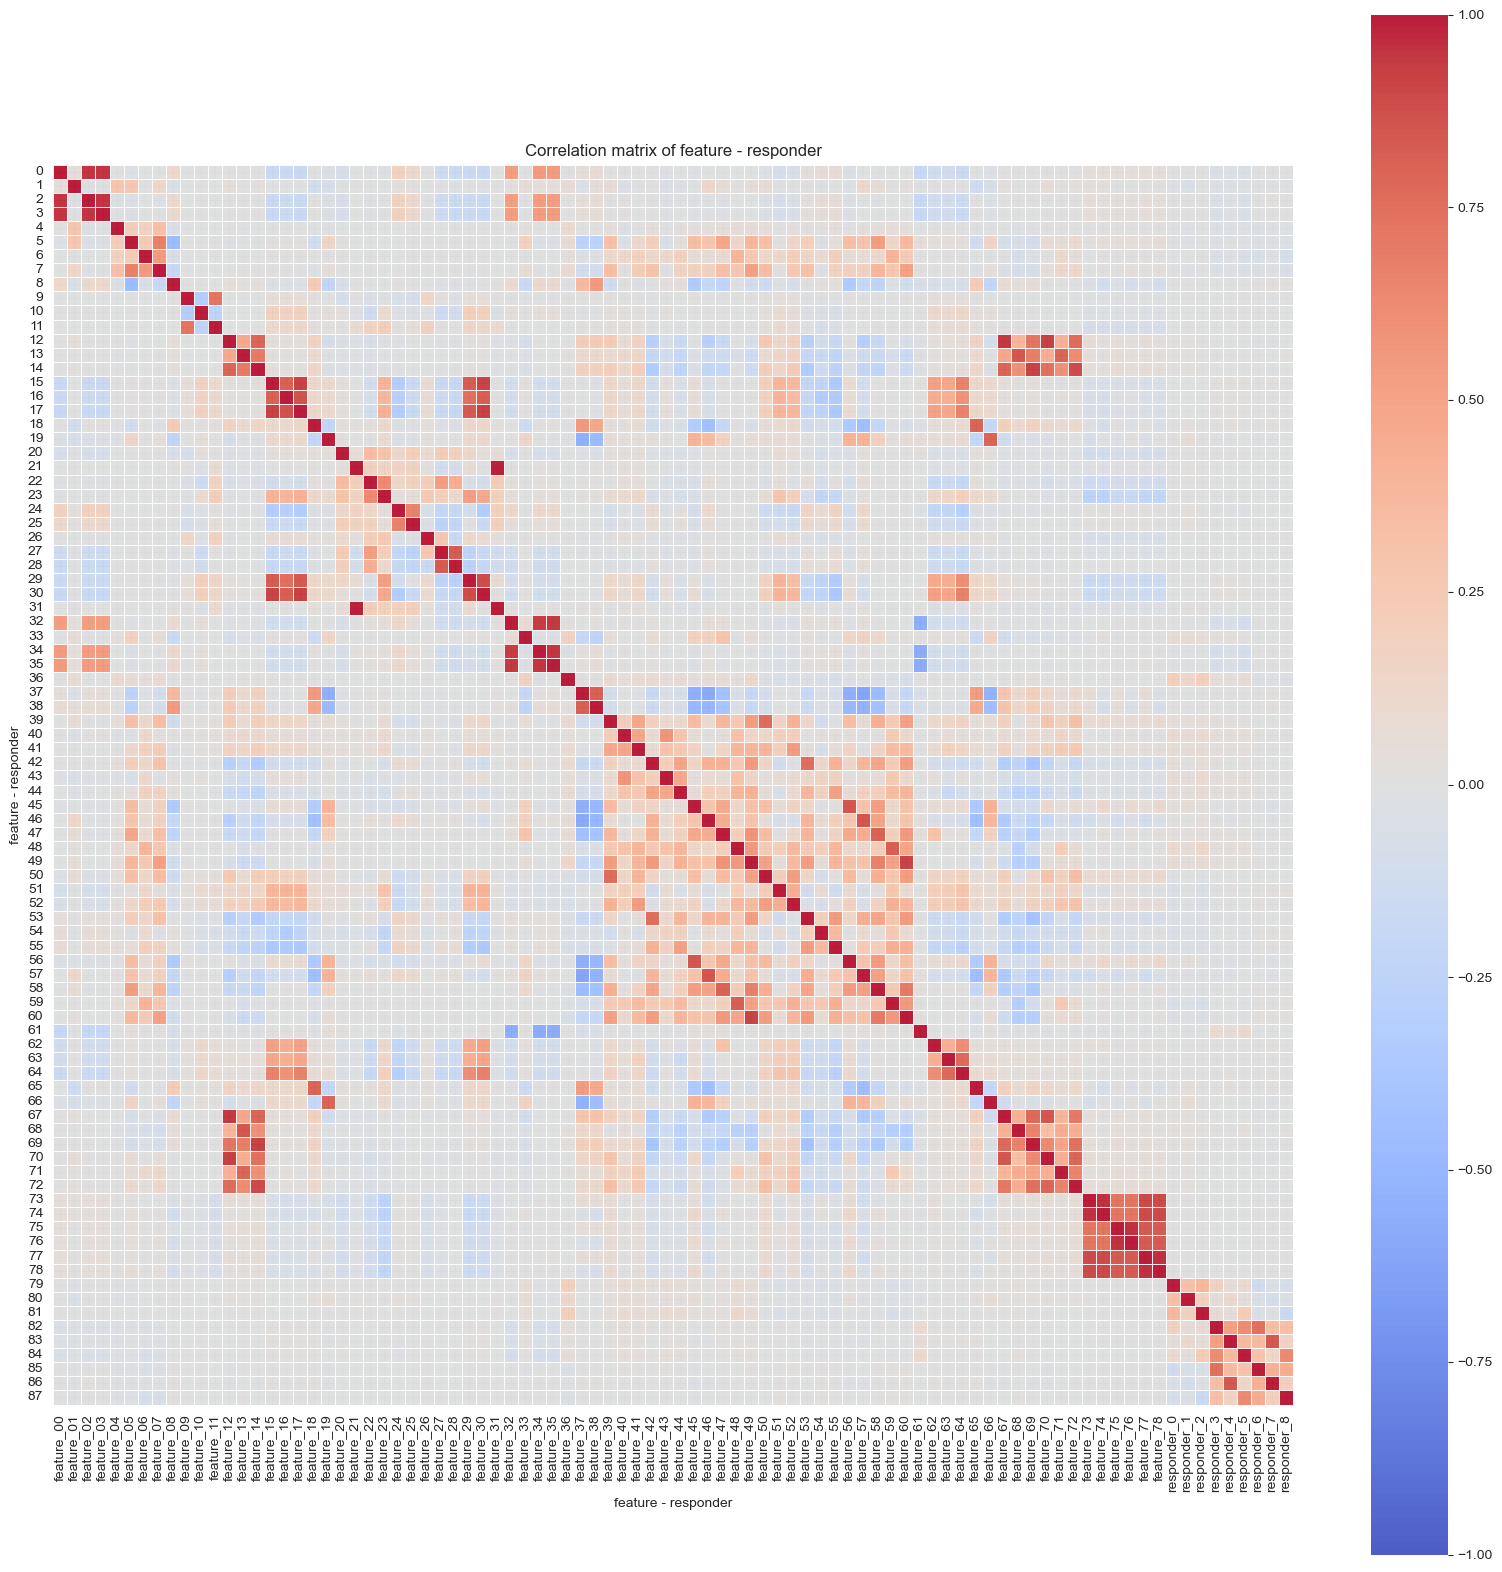

In [36]:
# the correlation matrix
plt.figure(figsize=(20, 20))
sns.heatmap(matrix_all_pd, square=True, cmap="coolwarm", alpha=0.9, vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='white')
plt.xlabel("feature - responder")
plt.ylabel("feature - responder")
plt.title('Correlation matrix of feature - responder')
plt.show()

By examining the two charts together, we can observe in the heat map some prominent squares (i.e., features with higher absolute correlation values):

- Features `feature_12`, `feature_13`, and `feature_14`, which exhibit very high correlations, all use `tag_9`.
- The range from `feature_4` to `feature_7` all utilize `tag_16`, with some of these features partially overlapping in their tag usage.
- From `feature_21` to `feature_30`, there is consistent use of `tag_0`.
- For `feature_39` to `feature_60`, `tag_3` is employed, along with frequent reuse of `tags_4, 5, and 12-15` within this feature set.
- The features from `feature_68` to `feature_72` also use `tag_9`.
- Lastly, `feature_73` to `feature_79` are associated with `tag_8`.

Therefore, through the patterns of tag usage, we can gain **partial** insight into the underlying reasons for the formation of the correlation matrix.

## File5: Responders.csv
responders.csv - metadata pertaining to the anonymized responders
#### Structure of responders:

In [43]:
responders = pd.read_csv(f"data/responders.csv")
responders

,responder,tag_0,tag_1,tag_2,tag_3,tag_4
0,responder_0,True,False,True,False,False
1,responder_1,True,False,False,True,False
2,responder_2,True,True,False,False,False
3,responder_3,False,False,True,False,True
4,responder_4,False,False,False,True,True
5,responder_5,False,True,False,False,True
6,responder_6,False,False,True,False,False
7,responder_7,False,False,False,True,False
8,responder_8,False,True,False,False,False


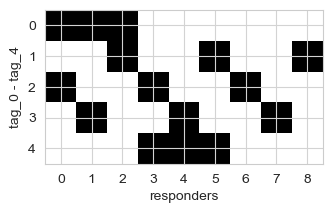

In [44]:
plt.figure(figsize=(9, 2))
plt.imshow(responders.iloc[:, 1:].T.values, cmap="gray_r")
plt.xlabel("responders")
plt.ylabel("tag_0 - tag_4")
plt.yticks(np.arange(5))
plt.xticks(np.arange(9))
plt.grid(color = 'lightgrey')
plt.show()

## File 6: Sample submission.csv
sample_submission.csv - This file illustrates the format of the predictions your model should make.

In [45]:
sub = pd.read_csv(f"data/sample_submission.csv")
print( f"shape = {sub.shape}" )
sub

shape = (39, 2)


,row_id,responder_6
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0
5,5,0.0
6,6,0.0
7,7,0.0
8,8,0.0
9,9,0.0


## Responders: analysis, statistics and distributions

In [53]:
col =[]
for i in range(9):
    col.append(f"responder_{i}") 

sample_df.select(col).describe()

statistic,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7,4.7127338e7
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",-0.001545,-0.000866,-0.000142,-0.01638,-0.012442,-0.016624,-0.002141,0.001476,-0.001114
"""std""",0.591211,0.587551,0.599179,0.819231,0.87284,0.734546,0.889852,0.916042,0.864412
"""min""",-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0
"""25%""",-0.19025,-0.163768,-0.199878,-0.310065,-0.383654,-0.225414,-0.382761,-0.419719,-0.334288
"""50%""",-0.004543,-0.023831,-0.000862,-0.025754,-0.04469,-0.009662,-0.025566,-0.039172,-0.008617
"""75%""",0.181948,0.127383,0.199062,0.261112,0.313263,0.200578,0.334321,0.355323,0.311202
"""max""",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


#### Interesting fact:
- The values of all variables are strictly within the range of `[-5, 5]`